In [9]:
# Install and import necessary libraries
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [10]:
asr = pd.read_csv(r"..\AirlineScrappedReview_Processed_StandardizedRoutes.csv")

In [11]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Passanger_Name      2807 non-null   object 
 1   Route               2807 non-null   object 
 2   Rating              2807 non-null   float64
 3   Verified            2807 non-null   object 
 4   Review_title        2807 non-null   object 
 5   Review_content      2807 non-null   object 
 6   Traveller_Type      2807 non-null   object 
 7   Class               2807 non-null   object 
 8   Start_Location      2807 non-null   object 
 9   End_Location        2807 non-null   object 
 10  Layover_Route       484 non-null    object 
 11  Start_Latitude      2747 non-null   float64
 12  Start_Longitude     2747 non-null   float64
 13  Start_Address       2747 non-null   object 
 14  End_Latitude        2708 non-null   float64
 15  End_Longitude       2708 non-null   float64
 16  End_Ad

In [12]:
asr = asr[asr['Class'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Various"].reset_index(drop=True)

In [13]:
# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr['Sentiment_Score'].describe())

print(f"\nSample reviews with sentiment scores:")
sample_display = asr[['Review_content', 'Sentiment_Score', 'Rating']].head(10)
for idx, row in sample_display.iterrows():
    print(f"\nRating: {row['Rating']:.1f} | Sentiment: {row['Sentiment_Score']:.3f}")
    print(f"Review: {row['Review_content'][:100]}...")# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr['Sentiment_Score'].describe())

✅ VADER lexicon ready!

STEP 3: CALCULATING SENTIMENT SCORES

Calculating sentiment scores using VADER...
✅ Sentiment scores calculated!

Sentiment Score Statistics:
count    2803.000000
mean        0.125699
std         0.781678
min        -0.997400
25%        -0.765000
50%         0.362600
75%         0.918600
max         0.999200
Name: Sentiment_Score, dtype: float64

Sample reviews with sentiment scores:

Rating: 1.0 | Sentiment: -0.799
Review: The airline lost my luggage and was absolutely awful throughout the entire trip. They gave me no upd...

Rating: 1.0 | Sentiment: 0.718
Review: We booked on the BA website, round trip flights from Seattle to Amman with a stop in London, in Busi...

Rating: 2.0 | Sentiment: -0.710
Review: First time flying with BA business class, never again. There are no boarding drinks provided. My mea...

Rating: 4.0 | Sentiment: -0.585
Review: You can buy sandwiches and crisps but don't expect a hot meal. Because the plane is a narrow body , ...

Rating: 7

In [14]:
# Select the columns for analysis
columns_to_analyze = ['Sentiment_Score', 'Has_Layover', 'Route_Standardized', 'Class', 'Traveller_Type', 'Verified']

# Display basic statistics for numerical columns
print("=== Statistics ===")
print(asr[['Sentiment_Score', 'Has_Layover']].describe())
print("\n")

print(asr[['Route_Standardized', 'Class', 'Traveller_Type', 'Verified']].describe(include=['object']))
print("\n")


# Display value counts for categorical columns
print("=== Class Distribution ===")
print(asr['Class'].value_counts())
print("\n")

print("=== Traveller Type Distribution ===")
print(asr['Traveller_Type'].value_counts())
print("\n")

print("=== Verification Status Distribution ===")
print(asr['Verified'].value_counts())
print("\n")

print("=== Has Layover Distribution ===")
print(asr['Has_Layover'].value_counts())
print("\n")

print("=== Top 10 Routes ===")
print(asr['Route_Standardized'].value_counts().head(10))
print("\n")

# Sentiment Score by Class
print("=== Average Sentiment Score by Class ===")
print(asr.groupby('Class')['Sentiment_Score'].agg(['mean', 'median', 'count']))
print("\n")

# Sentiment Score by Traveller Type
print("=== Average Sentiment Score by Traveller Type ===")
print(asr.groupby('Traveller_Type')['Sentiment_Score'].agg(['mean', 'median', 'count']))
print("\n")

# Sentiment Score by Verification Status
print("=== Average Sentiment Score by Verification Status ===")
print(asr.groupby('Verified')['Sentiment_Score'].agg(['mean', 'median', 'count']))
print("\n")

# Sentiment Score by Layover Status
print("=== Average Sentiment Score by Layover Status ===")
print(asr.groupby('Has_Layover')['Sentiment_Score'].agg(['mean', 'median', 'count']))

=== Statistics ===
       Sentiment_Score  Has_Layover
count      2803.000000  2803.000000
mean          0.125699     0.172315
std           0.781678     0.377722
min          -0.997400     0.000000
25%          -0.765000     0.000000
50%           0.362600     0.000000
75%           0.918600     0.000000
max           0.999200     1.000000


       Route_Standardized          Class  Traveller_Type      Verified
count                2803           2803            2803          2803
unique                928              4               4             2
top               LHR-JFK  Economy Class  Couple Leisure  Not Verified
freq                   35           1517             945          1738


=== Class Distribution ===
Class
Economy Class      1517
Business Class      862
Premium Economy     270
First Class         154
Name: count, dtype: int64


=== Traveller Type Distribution ===
Traveller_Type
Couple Leisure    945
Solo Leisure      859
Business          622
Family Leisure    377
Na

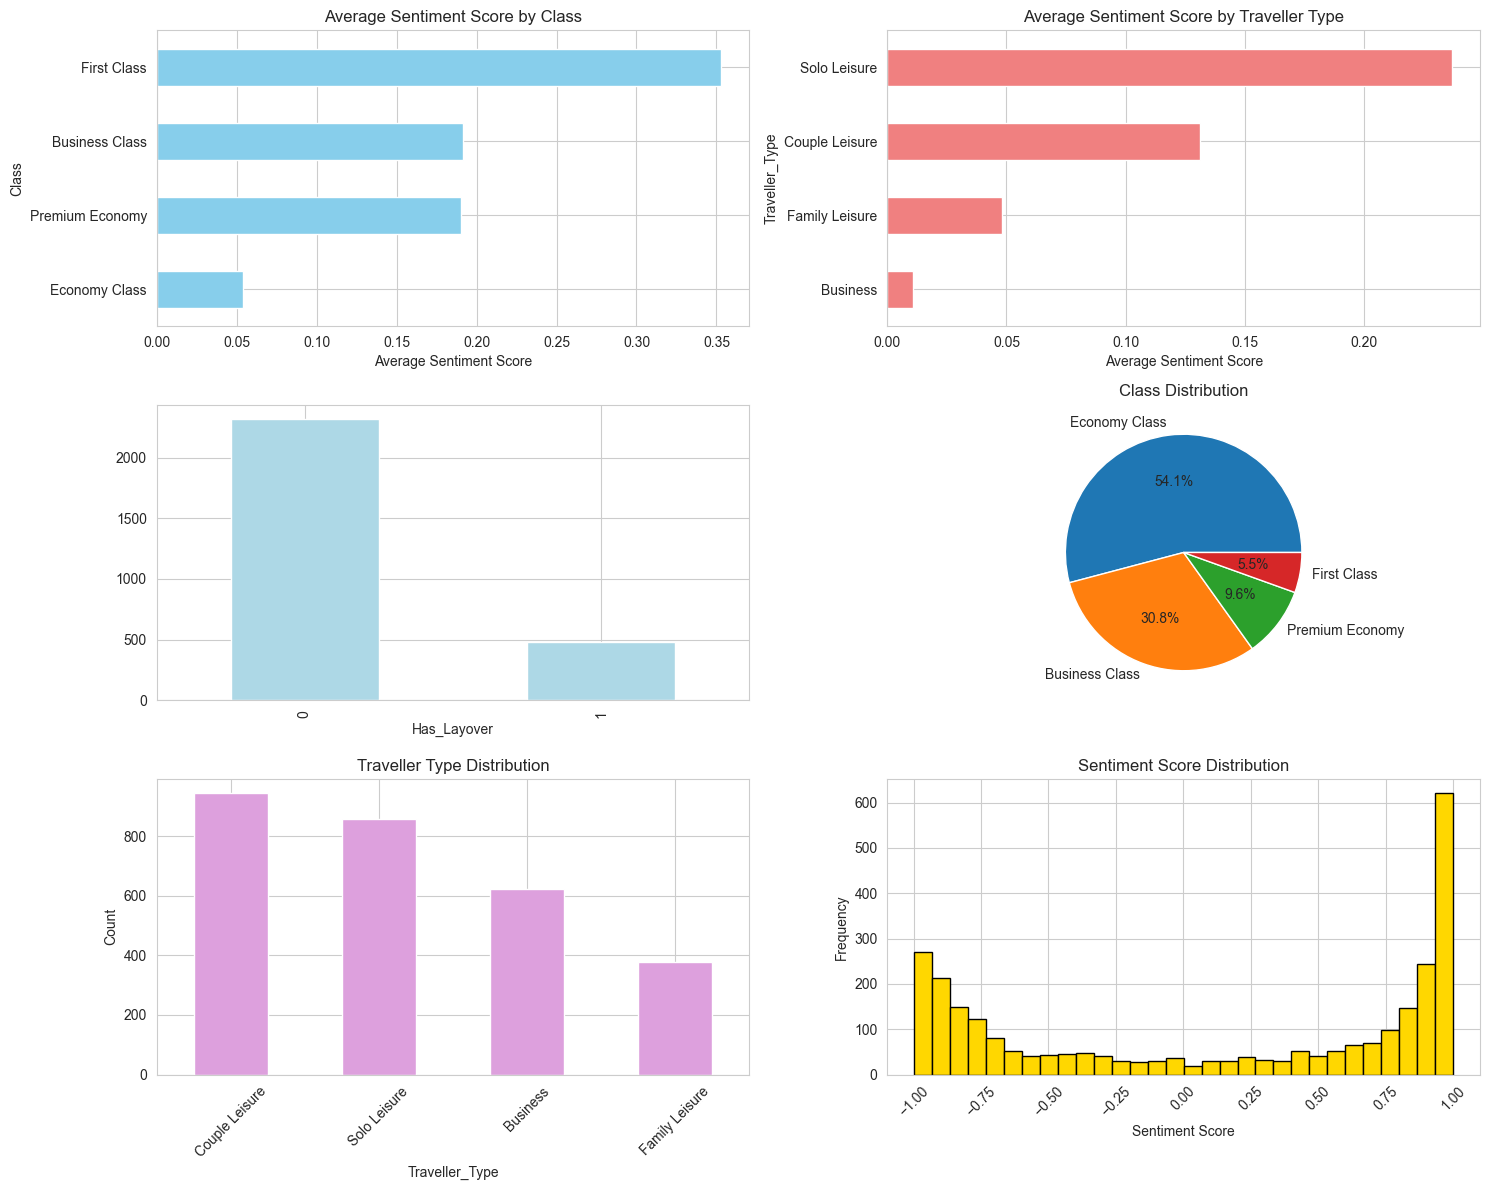

In [15]:
# Create visualizations
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 1. Sentiment Score by Class
asr.groupby('Class')['Sentiment_Score'].mean().sort_values().plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Average Sentiment Score by Class')
axes[0, 0].set_xlabel('Average Sentiment Score')

# 2. Sentiment Score by Traveller Type
asr.groupby('Traveller_Type')['Sentiment_Score'].mean().sort_values().plot(kind='barh', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Average Sentiment Score by Traveller Type')
axes[0, 1].set_xlabel('Average Sentiment Score')

# 3. Has layover Distribution
asr['Has_Layover'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightblue')
axes[2, 1].set_title('Has Layover Distribution')
axes[2, 1].set_ylabel('Count')
axes[2, 1].tick_params(axis='x', rotation=45)

# 4. Class Distribution
asr['Class'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%')
axes[1, 1].set_title('Class Distribution')
axes[1, 1].set_ylabel('')

# 5. Traveller Type Distribution
asr['Traveller_Type'].value_counts().plot(kind='bar', ax=axes[2, 0], color='plum')
axes[2, 0].set_title('Traveller Type Distribution')
axes[2, 0].set_ylabel('Count')
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Sentiment Score Distribution
axes[2, 1].hist(asr['Sentiment_Score'], bins=30, color='gold', edgecolor='black')
axes[2, 1].set_title('Sentiment Score Distribution')
axes[2, 1].set_xlabel('Sentiment Score')
axes[2, 1].set_ylabel('Frequency')





plt.tight_layout()
plt.show()

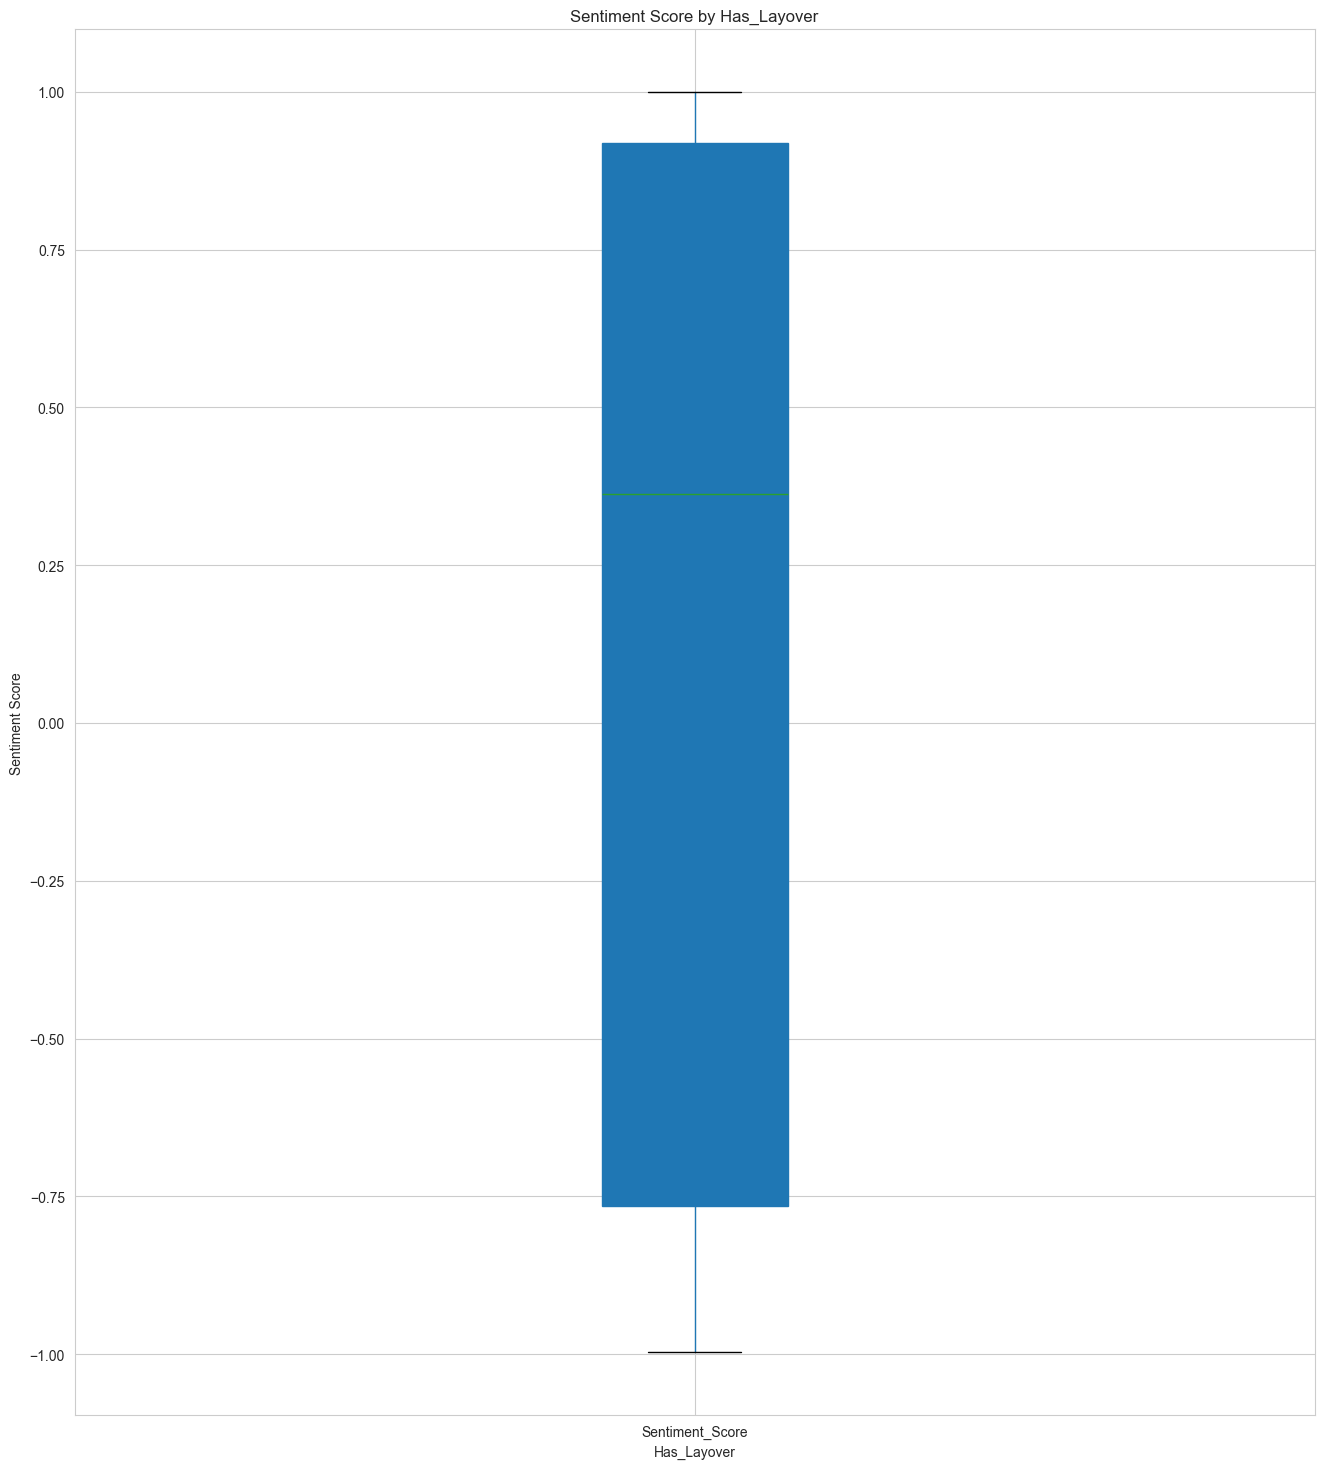

In [16]:
# Create figure for boxplots and correlation analysis
fig, axes = plt.subplots(1, 1, figsize=(16, 18))


# 2. Box plot: Sentiment Score by Has_Layover
asr.boxplot(column='Sentiment_Score', ax=axes, patch_artist=True)
axes.set_title('Sentiment Score by Has_Layover')
axes.set_xlabel('Has_Layover')
axes.set_ylabel('Sentiment Score')
plt.sca(axes)


FLIGHT REVIEW FEATURE ANALYSIS

Total Records: 2803

Dataset Shape: (2803, 20)


1. TRAVELLER TYPE ANALYSIS
--------------------------------------------------------------------------------

Distribution:
  Couple Leisure: 945 (33.71%)
  Solo Leisure: 859 (30.65%)
  Business: 622 (22.19%)
  Family Leisure: 377 (13.45%)

Unique Traveller Types: 4
Most Common: Couple Leisure (945 records)


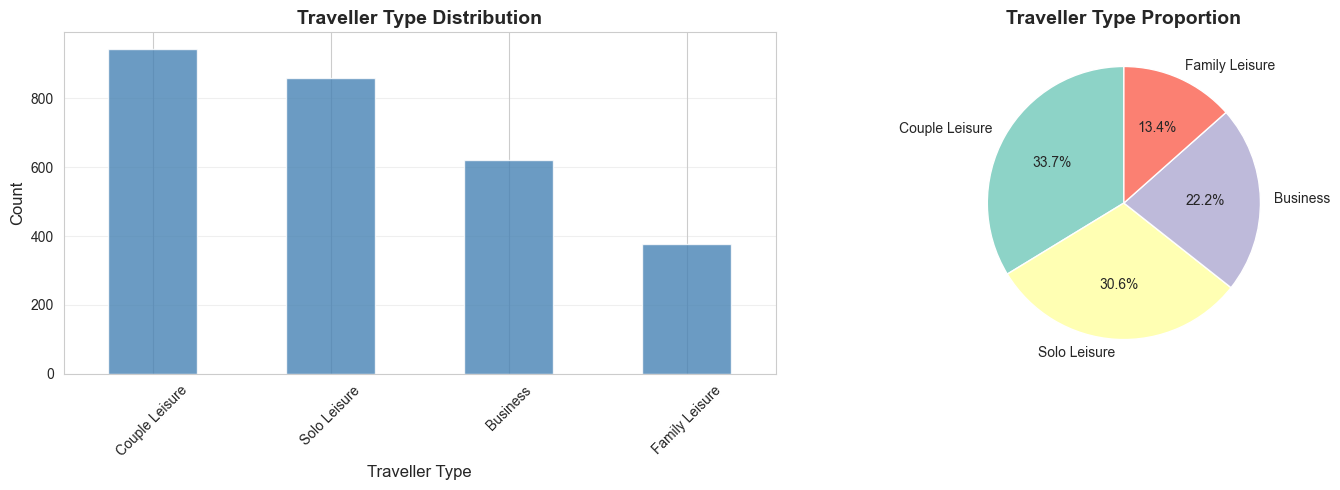



2. FLIGHT CLASS ANALYSIS
--------------------------------------------------------------------------------

Distribution:
  Economy Class: 1517 (54.12%)
  Business Class: 862 (30.75%)
  Premium Economy: 270 (9.63%)
  First Class: 154 (5.49%)

Unique Classes: 4


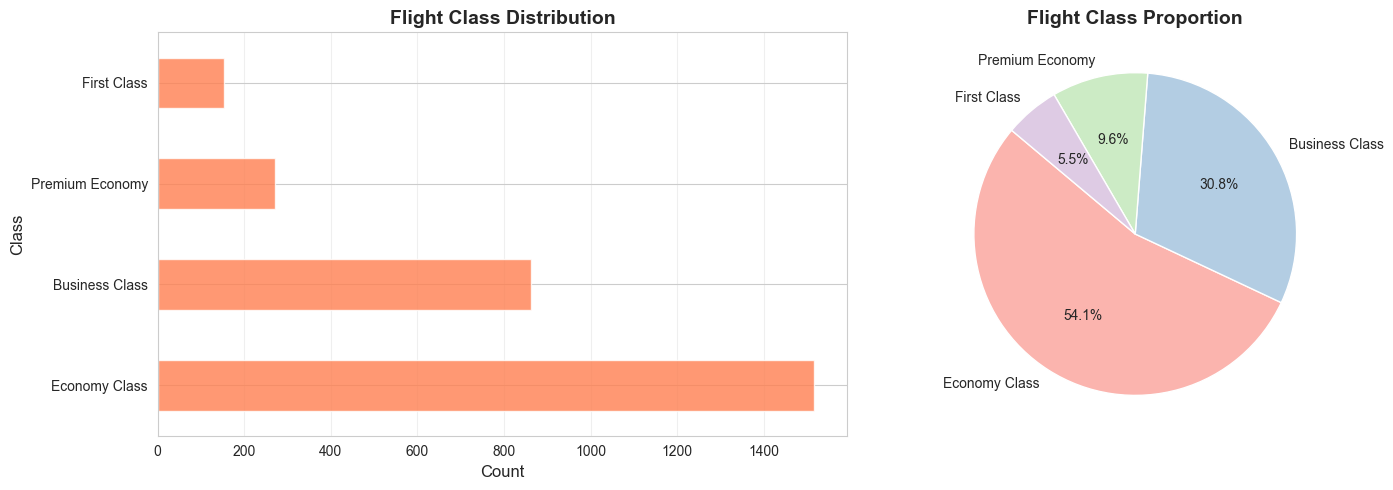



3. VERIFICATION STATUS ANALYSIS
--------------------------------------------------------------------------------

Distribution:
  Verified: 1738 (62.00%)
  Verified: 1065 (38.00%)


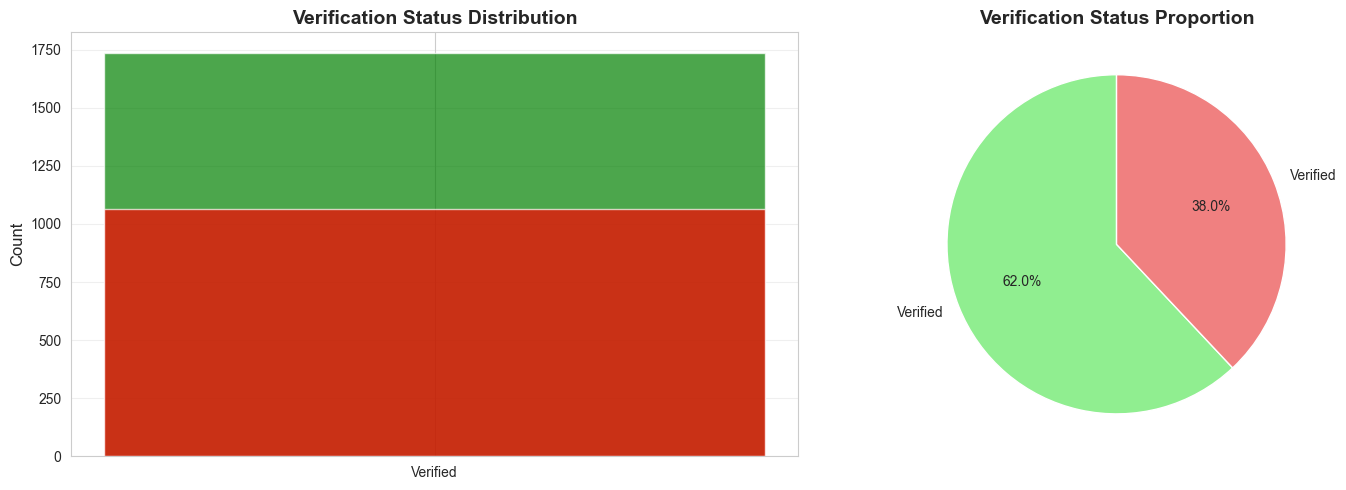



4. SENTIMENT SCORE ANALYSIS
--------------------------------------------------------------------------------

Descriptive Statistics:
  Mean: 0.1257
  Median: 0.3626
  Std Dev: 0.7817
  Min: -0.9974
  Max: 0.9992
  25th Percentile: -0.7650
  75th Percentile: 0.9186

Sentiment Categories:
  Positive (>0.05): 1557 (55.55%)
  Neutral (-0.05 to 0.05): 38 (1.36%)
  Negative (<-0.05): 1208 (43.10%)


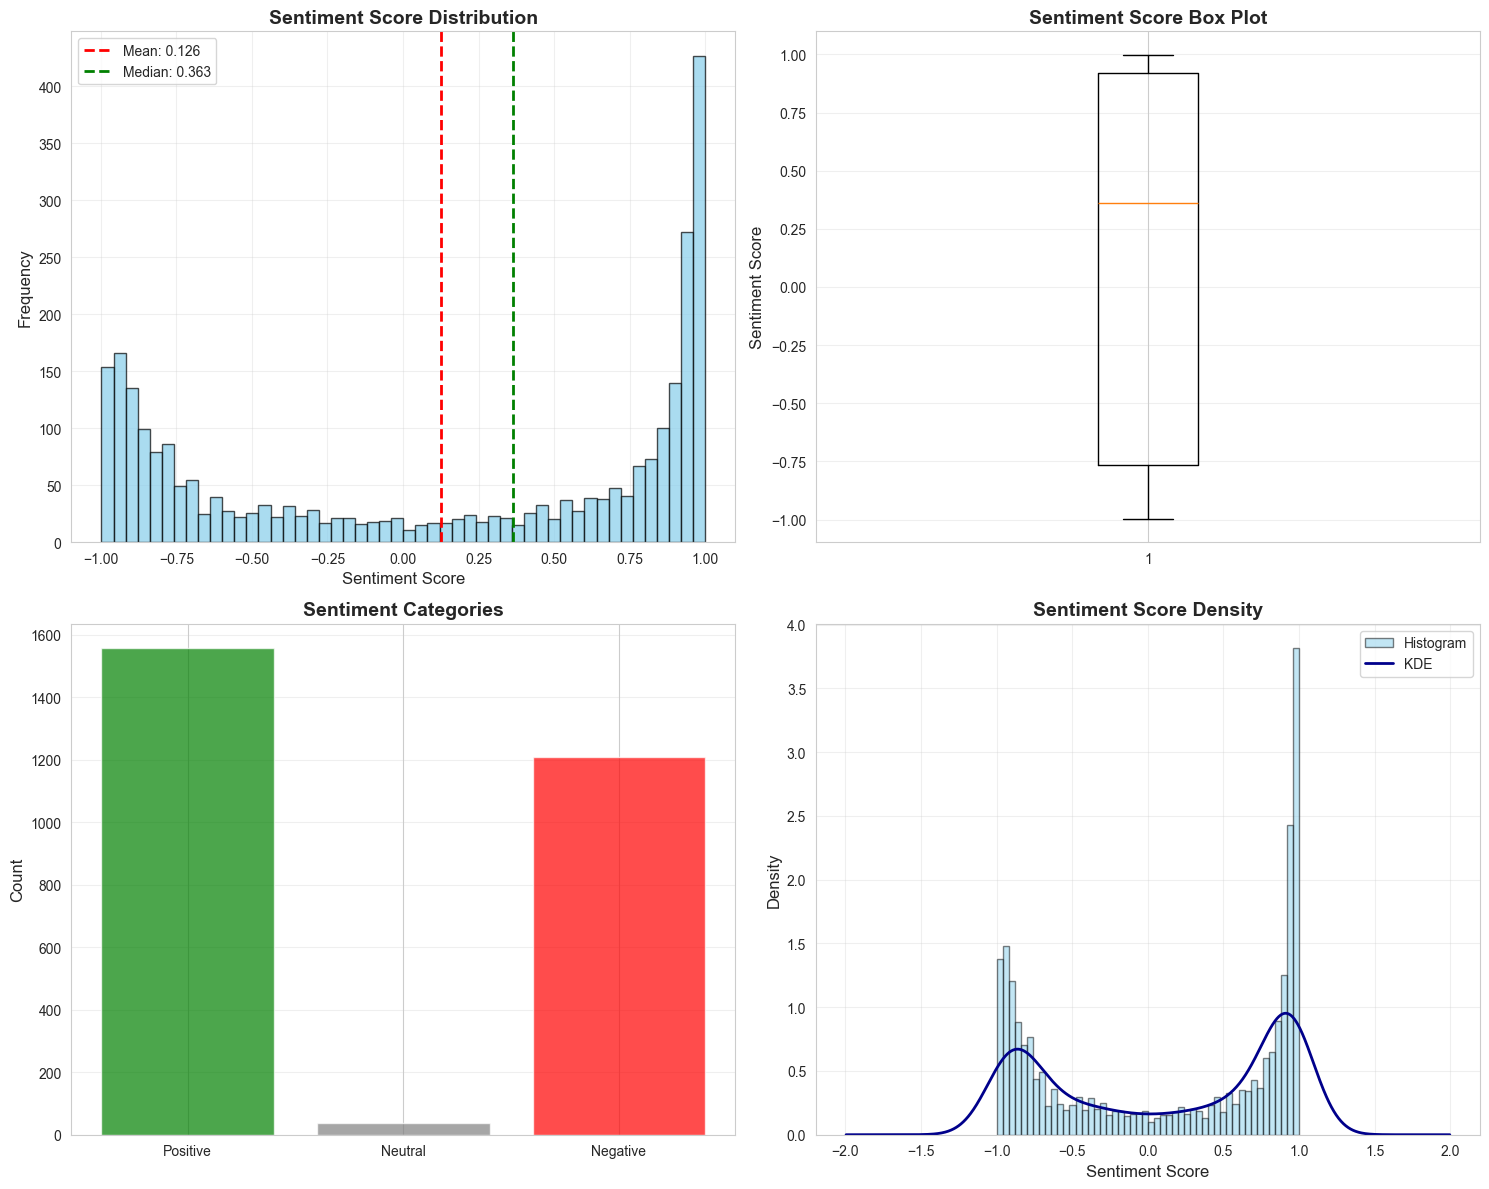



5. LAYOVER ANALYSIS
--------------------------------------------------------------------------------

Distribution:
  Direct Flight: 2320 (82.77%)
  Has Layover: 483 (17.23%)


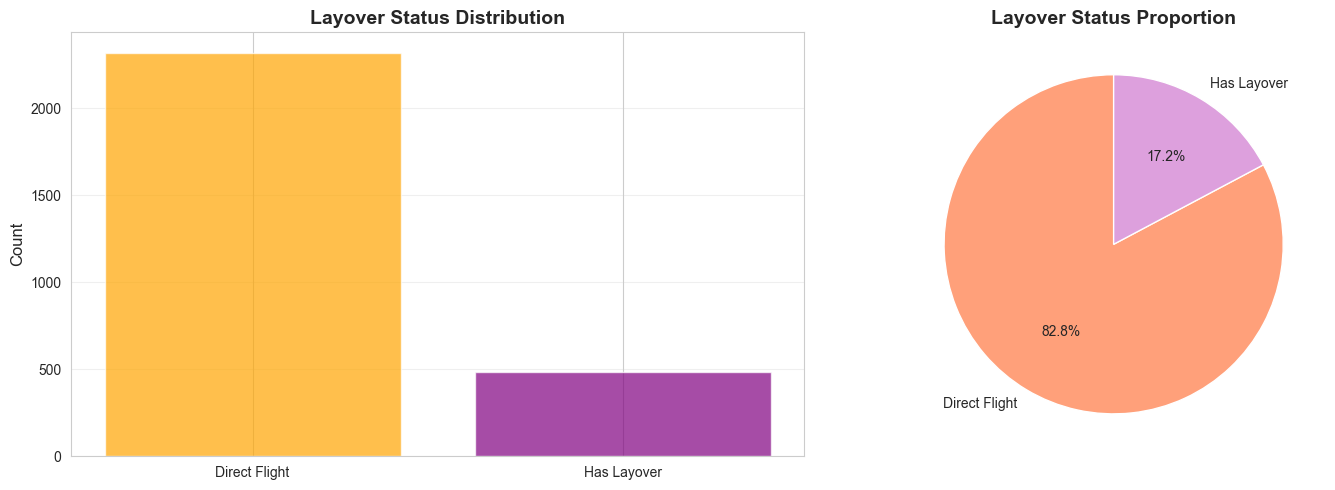



6. CROSS-FEATURE ANALYSIS
--------------------------------------------------------------------------------

Average Sentiment by Traveller Type:
                    mean  count       std
Traveller_Type                           
Business        0.010686    622  0.777676
Couple Leisure  0.131205    945  0.777960
Family Leisure  0.048213    377  0.815323
Solo Leisure    0.236930    859  0.758854

Average Sentiment by Class:
                     mean  count       std
Class                                     
Business Class   0.191417    862  0.783090
Economy Class    0.053798   1517  0.775479
First Class      0.352940    154  0.741698
Premium Economy  0.190255    270  0.789341

Average Sentiment by Layover Status:
                   mean  count       std
Direct Flight  0.142625   2320  0.775034
Has Layover    0.044401    483  0.808729


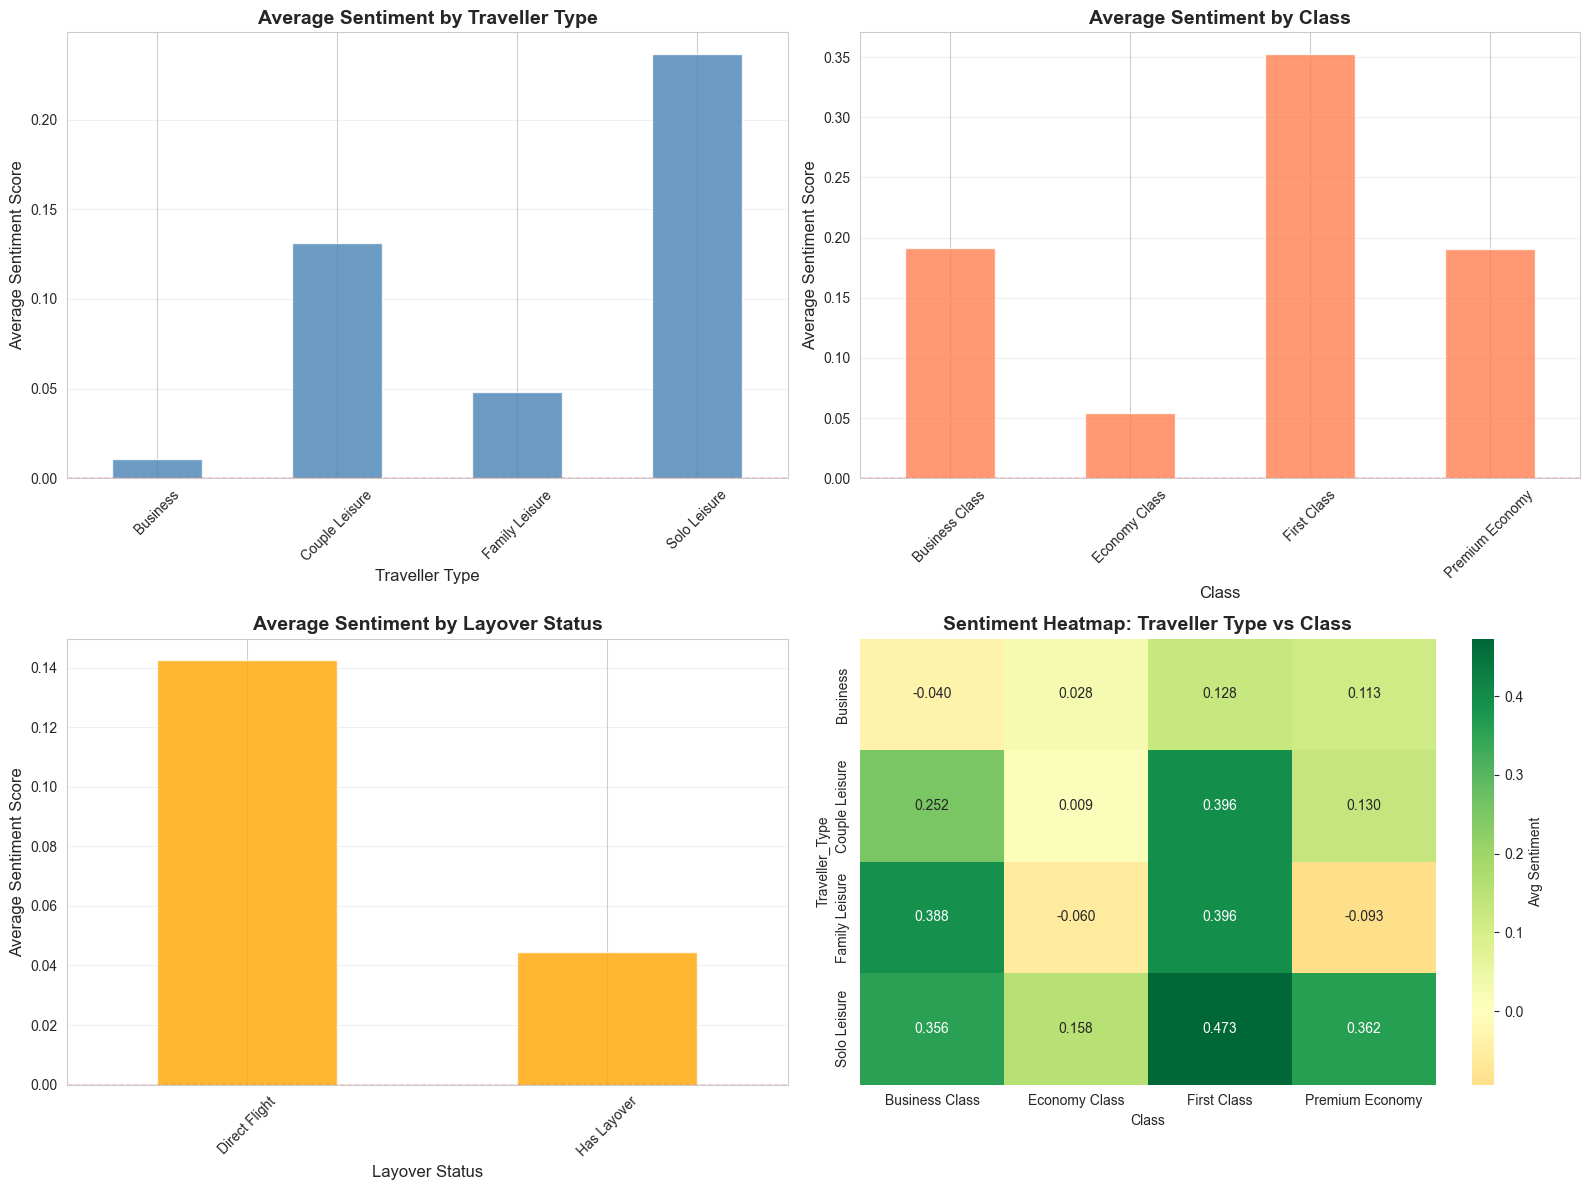



7. VERIFICATION VS SENTIMENT
--------------------------------------------------------------------------------
                  mean  count       std
Not Verified  0.151727   1738  0.775415
Verified      0.083224   1065  0.790317

T-test (Verified vs Not Verified):
  T-statistic: nan
  P-value: nan


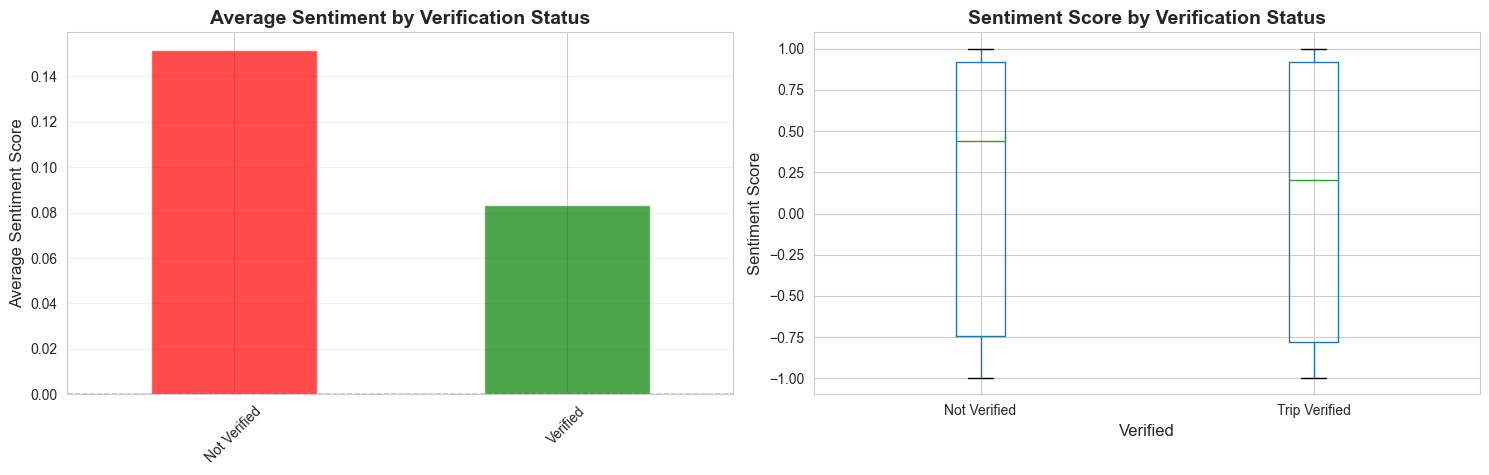


ANALYSIS COMPLETE!
All plots have been saved as PNG files.


In [18]:
from scipy import stats

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


print("=" * 80)
print("FLIGHT REVIEW FEATURE ANALYSIS")
print("=" * 80)
print(f"\nTotal Records: {len(asr)}")
print(f"\nDataset Shape: {asr.shape}")
print("\n" + "=" * 80)

# ============================================================================
# 1. TRAVELLER TYPE ANALYSIS
# ============================================================================
print("\n1. TRAVELLER TYPE ANALYSIS")
print("-" * 80)

# Count and percentage
traveller_counts = asr['Traveller_Type'].value_counts()
traveller_pct = asr['Traveller_Type'].value_counts(normalize=True) * 100

print("\nDistribution:")
for ttype, count in traveller_counts.items():
    print(f"  {ttype}: {count} ({traveller_pct[ttype]:.2f}%)")

# Statistical summary
print(f"\nUnique Traveller Types: {asr['Traveller_Type'].nunique()}")
print(f"Most Common: {traveller_counts.index[0]} ({traveller_counts.iloc[0]} records)")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
traveller_counts.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Traveller Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Traveller Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = plt.cm.Set3(range(len(traveller_counts)))
axes[1].pie(traveller_counts, labels=traveller_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
axes[1].set_title('Traveller Type Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('1_traveller_type_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 2. FLIGHT CLASS ANALYSIS
# ============================================================================
print("\n\n2. FLIGHT CLASS ANALYSIS")
print("-" * 80)

# Count and percentage
class_counts = asr['Class'].value_counts()
class_pct = asr['Class'].value_counts(normalize=True) * 100

print("\nDistribution:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} ({class_pct[cls]:.2f}%)")

print(f"\nUnique Classes: {asr['Class'].nunique()}")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
class_counts.plot(kind='barh', ax=axes[0], color='coral', alpha=0.8)
axes[0].set_title('Flight Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Class', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.Pastel1(range(len(class_counts))))
axes[1].set_title('Flight Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('2_class_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. VERIFICATION STATUS ANALYSIS
# ============================================================================
print("\n\n3. VERIFICATION STATUS ANALYSIS")
print("-" * 80)

# Count and percentage
verified_counts = asr['Verified'].value_counts()
verified_pct = asr['Verified'].value_counts(normalize=True) * 100

print("\nDistribution:")
for status, count in verified_counts.items():
    status_label = "Verified" if status else "Not Verified"
    print(f"  {status_label}: {count} ({verified_pct[status]:.2f}%)")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
verified_labels = ['Verified' if x else 'Not Verified' for x in verified_counts.index]
axes[0].bar(verified_labels, verified_counts.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Verification Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(verified_counts, labels=verified_labels, autopct='%1.1f%%',
            colors=['lightgreen', 'lightcoral'], startangle=90)
axes[1].set_title('Verification Status Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('3_verification_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. SENTIMENT SCORE ANALYSIS
# ============================================================================
print("\n\n4. SENTIMENT SCORE ANALYSIS")
print("-" * 80)

# Remove any null values for sentiment analysis
sentiment_data = asr['Sentiment_Score'].dropna()

# Statistical summary
print("\nDescriptive Statistics:")
print(f"  Mean: {sentiment_data.mean():.4f}")
print(f"  Median: {sentiment_data.median():.4f}")
print(f"  Std Dev: {sentiment_data.std():.4f}")
print(f"  Min: {sentiment_data.min():.4f}")
print(f"  Max: {sentiment_data.max():.4f}")
print(f"  25th Percentile: {sentiment_data.quantile(0.25):.4f}")
print(f"  75th Percentile: {sentiment_data.quantile(0.75):.4f}")

# Categorize sentiment
positive = (sentiment_data > 0.05).sum()
neutral = ((sentiment_data >= -0.05) & (sentiment_data <= 0.05)).sum()
negative = (sentiment_data < -0.05).sum()

print(f"\nSentiment Categories:")
print(f"  Positive (>0.05): {positive} ({positive/len(sentiment_data)*100:.2f}%)")
print(f"  Neutral (-0.05 to 0.05): {neutral} ({neutral/len(sentiment_data)*100:.2f}%)")
print(f"  Negative (<-0.05): {negative} ({negative/len(sentiment_data)*100:.2f}%)")

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram
axes[0, 0].hist(sentiment_data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(sentiment_data.mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {sentiment_data.mean():.3f}')
axes[0, 0].axvline(sentiment_data.median(), color='green', linestyle='--', 
                    linewidth=2, label=f'Median: {sentiment_data.median():.3f}')
axes[0, 0].set_title('Sentiment Score Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sentiment Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot
axes[0, 1].boxplot(sentiment_data, vert=True)
axes[0, 1].set_title('Sentiment Score Box Plot', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Sentiment Score', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

# Sentiment category bar chart
categories = ['Positive', 'Neutral', 'Negative']
counts = [positive, neutral, negative]
colors_cat = ['green', 'gray', 'red']
axes[1, 0].bar(categories, counts, color=colors_cat, alpha=0.7)
axes[1, 0].set_title('Sentiment Categories', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

# KDE plot
axes[1, 1].hist(sentiment_data, bins=50, density=True, alpha=0.5, color='skyblue', 
                edgecolor='black', label='Histogram')
sentiment_data.plot(kind='kde', ax=axes[1, 1], color='darkblue', linewidth=2, label='KDE')
axes[1, 1].set_title('Sentiment Score Density', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment Score', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('4_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5. LAYOVER ANALYSIS
# ============================================================================
print("\n\n5. LAYOVER ANALYSIS")
print("-" * 80)

# Count and percentage
layover_counts = asr['Has_Layover'].value_counts()
layover_pct = asr['Has_Layover'].value_counts(normalize=True) * 100

print("\nDistribution:")
for status, count in layover_counts.items():
    status_label = "Has Layover" if status else "Direct Flight"
    print(f"  {status_label}: {count} ({layover_pct[status]:.2f}%)")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
layover_labels = ['Has Layover' if x else 'Direct Flight' for x in layover_counts.index]
axes[0].bar(layover_labels, layover_counts.values, color=['orange', 'purple'], alpha=0.7)
axes[0].set_title('Layover Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(layover_counts, labels=layover_labels, autopct='%1.1f%%',
            colors=['lightsalmon', 'plum'], startangle=90)
axes[1].set_title('Layover Status Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('5_layover_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. CROSS-FEATURE ANALYSIS
# ============================================================================
print("\n\n6. CROSS-FEATURE ANALYSIS")
print("-" * 80)

# Sentiment by Traveller Type
print("\nAverage Sentiment by Traveller Type:")
sentiment_by_traveller = asr.groupby('Traveller_Type')['Sentiment_Score'].agg(['mean', 'count', 'std'])
print(sentiment_by_traveller)

# Sentiment by Class
print("\nAverage Sentiment by Class:")
sentiment_by_class = asr.groupby('Class')['Sentiment_Score'].agg(['mean', 'count', 'std'])
print(sentiment_by_class)

# Sentiment by Layover
print("\nAverage Sentiment by Layover Status:")
sentiment_by_layover = asr.groupby('Has_Layover')['Sentiment_Score'].agg(['mean', 'count', 'std'])
sentiment_by_layover.index = ['Direct Flight', 'Has Layover']
print(sentiment_by_layover)

# Plotting cross-analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sentiment by Traveller Type
sentiment_by_traveller['mean'].plot(kind='bar', ax=axes[0, 0], color='steelblue', alpha=0.8)
axes[0, 0].set_title('Average Sentiment by Traveller Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Traveller Type', fontsize=12)
axes[0, 0].set_ylabel('Average Sentiment Score', fontsize=12)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Sentiment by Class
sentiment_by_class['mean'].plot(kind='bar', ax=axes[0, 1], color='coral', alpha=0.8)
axes[0, 1].set_title('Average Sentiment by Class', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Class', fontsize=12)
axes[0, 1].set_ylabel('Average Sentiment Score', fontsize=12)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Sentiment by Layover
sentiment_by_layover['mean'].plot(kind='bar', ax=axes[1, 0], color='orange', alpha=0.8)
axes[1, 0].set_title('Average Sentiment by Layover Status', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Layover Status', fontsize=12)
axes[1, 0].set_ylabel('Average Sentiment Score', fontsize=12)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Heatmap: Sentiment by Traveller Type and Class
pivot_table = asr.pivot_table(values='Sentiment_Score', 
                              index='Traveller_Type', 
                              columns='Class', 
                              aggfunc='mean')
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0, ax=axes[1, 1], cbar_kws={'label': 'Avg Sentiment'})
axes[1, 1].set_title('Sentiment Heatmap: Traveller Type vs Class', 
                     fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('6_cross_feature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 7. VERIFICATION VS SENTIMENT
# ============================================================================
print("\n\n7. VERIFICATION VS SENTIMENT")
print("-" * 80)

sentiment_by_verified = asr.groupby('Verified')['Sentiment_Score'].agg(['mean', 'count', 'std'])
sentiment_by_verified.index = ['Not Verified', 'Verified']
print(sentiment_by_verified)

# Statistical test
verified_sentiment = asr[asr['Verified'] == True]['Sentiment_Score'].dropna()
not_verified_sentiment = asr[asr['Verified'] == False]['Sentiment_Score'].dropna()
t_stat, p_value = stats.ttest_ind(verified_sentiment, not_verified_sentiment)
print(f"\nT-test (Verified vs Not Verified):")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.4f}")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
sentiment_by_verified['mean'].plot(kind='bar', ax=axes[0], 
                                   color=['red', 'green'], alpha=0.7)
axes[0].set_title('Average Sentiment by Verification Status', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Sentiment Score', fontsize=12)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Box plot comparison
asr.boxplot(column='Sentiment_Score', by='Verified', ax=axes[1])
axes[1].set_title('Sentiment Score by Verification Status', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Verified', fontsize=12)
axes[1].set_ylabel('Sentiment Score', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.savefig('7_verification_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("All plots have been saved as PNG files.")
print("=" * 80)

In [24]:
eqdf2 = pd.read_csv('../../Passanger_booking_data.csv')
eqdf2 = eqdf2.drop_duplicates()

PASSENGER BOOKING DATA - FLIGHT HOUR & ROUTE ANALYSIS

Total Bookings: 49,283

1. FLIGHT HOUR ANALYSIS
--------------------------------------------------------------------------------

Flight Hour Statistics:
  Most Popular Hour: 8:00
  Average Hour: 9.1
  Earliest Flight: 0:00
  Latest Flight: 23:00


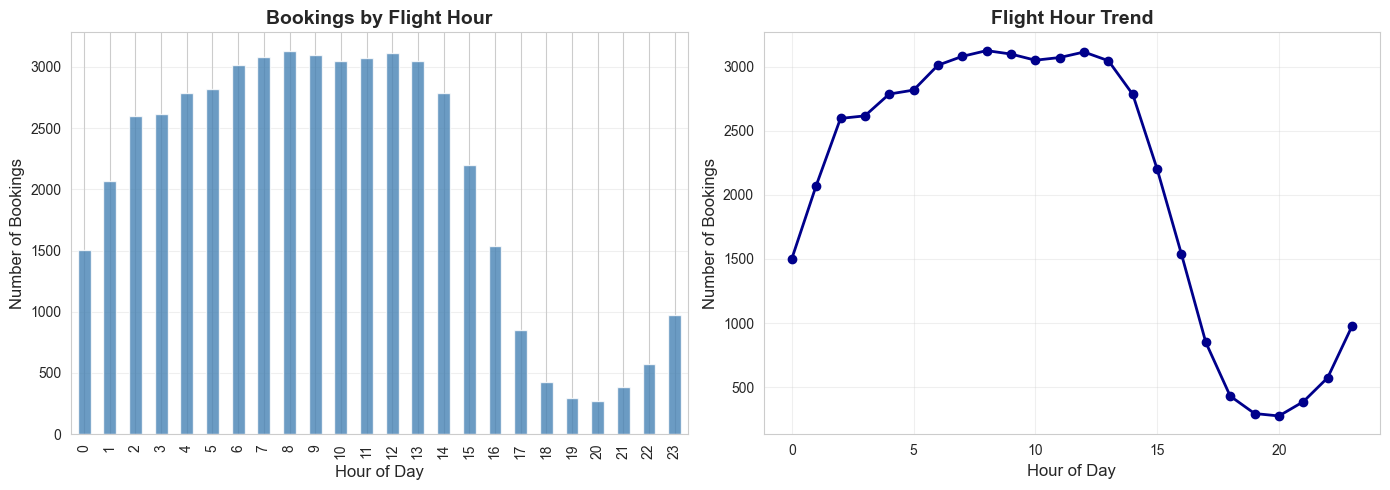



2. ROUTE ANALYSIS
--------------------------------------------------------------------------------

Total Routes: 799

Top 10 Most Popular Routes:
   1. AKLKUL: 2620 bookings (5.3%)
   2. PENTPE: 912 bookings (1.9%)
   3. MELSGN: 833 bookings (1.7%)
   4. ICNSIN: 793 bookings (1.6%)
   5. DMKKIX: 729 bookings (1.5%)
   6. ICNSYD: 683 bookings (1.4%)
   7. DMKPER: 677 bookings (1.4%)
   8. DPSICN: 658 bookings (1.3%)
   9. DMKOOL: 652 bookings (1.3%)
  10. MELTPE: 637 bookings (1.3%)


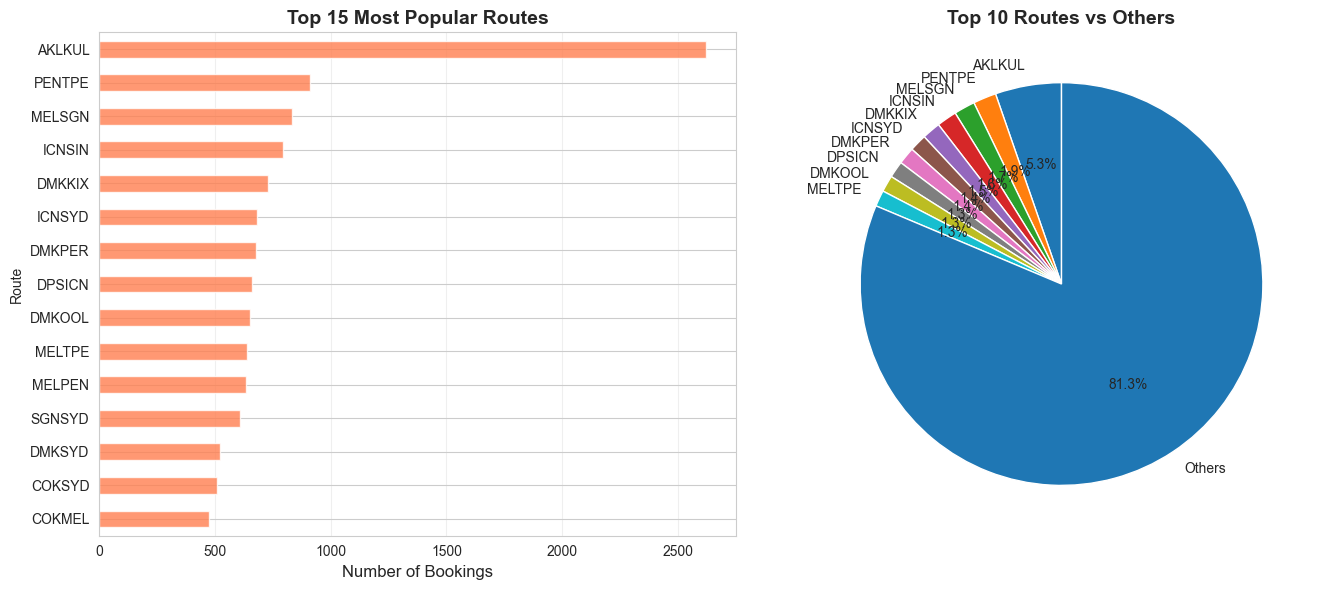


ANALYSIS COMPLETE!


In [26]:
print("=" * 80)
print("PASSENGER BOOKING DATA - FLIGHT HOUR & ROUTE ANALYSIS")
print("=" * 80)
print(f"\nTotal Bookings: {len(eqdf2):,}")

# ============================================================================
# FLIGHT HOUR ANALYSIS
# ============================================================================
print("\n1. FLIGHT HOUR ANALYSIS")
print("-" * 80)

# Basic statistics
print(f"\nFlight Hour Statistics:")
print(f"  Most Popular Hour: {eqdf2['flight_hour'].mode()[0]}:00")
print(f"  Average Hour: {eqdf2['flight_hour'].mean():.1f}")
print(f"  Earliest Flight: {eqdf2['flight_hour'].min()}:00")
print(f"  Latest Flight: {eqdf2['flight_hour'].max()}:00")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly distribution
eqdf2['flight_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], 
                                                       color='steelblue', alpha=0.8)
axes[0].set_title('Bookings by Flight Hour', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Number of Bookings', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Time trend
eqdf2['flight_hour'].value_counts().sort_index().plot(kind='line', ax=axes[1], 
                                                       color='darkblue', marker='o', linewidth=2)
axes[1].set_title('Flight Hour Trend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Number of Bookings', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('8_flight_hour_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# ROUTE ANALYSIS
# ============================================================================
print("\n\n2. ROUTE ANALYSIS")
print("-" * 80)

# Basic statistics
route_counts = eqdf2['route'].value_counts()
print(f"\nTotal Routes: {eqdf2['route'].nunique()}")
print(f"\nTop 10 Most Popular Routes:")
for i, (route, count) in enumerate(route_counts.head(10).items(), 1):
    pct = (count / len(eqdf2)) * 100
    print(f"  {i:2d}. {route}: {count} bookings ({pct:.1f}%)")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 routes
route_counts.head(15).sort_values().plot(kind='barh', ax=axes[0], 
                                          color='coral', alpha=0.8)
axes[0].set_title('Top 15 Most Popular Routes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Bookings', fontsize=12)
axes[0].set_ylabel('Route', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# Route distribution
top_10 = route_counts.head(10)
other = len(eqdf2) - top_10.sum()
pie_data = pd.concat([top_10, pd.Series({'Others': other})])
axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Top 10 Routes vs Others', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('9_route_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)